# C4TUNE — predicting C4 photosynthesis kinetic parameters from gas-exchange curves (Colab demo)

**Paper:** Wendering, P., Ferguson, J., Xu, R., Kromdijk, J., & Nikoloski, Z. (2026).
*Kinetic parameter prediction using neural networks identifies limitations to C4 photosynthesis.*
New Phytologist 251(3):1578–1594. DOI: [10.1111/nph.71280](https://doi.org/10.1111/nph.71280) (PMCID PMC13326549, CC-BY 4.0).

**Author code:** [pwendering/C4TUNE](https://github.com/pwendering/C4TUNE), pinned commit `8796b700dc001ce3de0f59b1a1481778cc74bbe8` (MIT-type LICENSE file in repository).
This notebook runs the **author's own pretrained network and code** — no AI re-implementation of the method is used.

**Scope (partial demonstration):** apply the pretrained C4TUNE network (checkpoint `c4tune-epoch-60.pth`,
2025-03-21 run) to the **author-provided measured maize A/CO₂ and A/light curves (2022 season, 68 MAGIC
genotypes)** and predict the 236 kinetic parameters of the Wang et al. (2021) C4 photosynthesis model.
This is the prediction step of the paper's "maize application" phase; training, the Matlab ODE
re-simulation, the 2023 season and the limiting-factor analysis are **not** executed here. A one-example
run does not verify the paper's published dataset-level accuracies.

**実行内容（日本語）:** 論文著者自身の学習済み C4TUNE ネットワークとコードをそのまま使い、2022 年に測定された
トウモロコシ 68 遺伝型の A/CO₂・A/light 曲線から、C4 光合成モデルの 236 個の速度論パラメータを予測します。
学習・ODE 再シミュレーション・2023 年データ・限定因子解析は範囲外です（部分的なデモンストレーション）。


## Runtime selection — ランタイムの選択

**Recommended: CPU runtime** (Runtime ▸ Change runtime type ▸ CPU). The model is tiny (~2.4 MB);
inference takes seconds on CPU. The author's own `minimal_example_prediction.py` selects the CPU
device (`config.training.device = "cpu"`), so the same computation runs even if a GPU runtime is
allocated — nothing in this demo requires a GPU.

**推奨は CPU ランタイムです。** モデルは約 2.4 MB と小さく、推論は CPU で数秒です。
著者のサンプルスクリプト自体が CPU を選択するため、GPU ランタイムでも計算内容は同じです。
**Expected duration ≈ 5–10 min end-to-end** (dominated by setup and one Zenodo download; measured
times are shown in the outputs). Downloads: author repository ≈ 120 MB, training-data archive for
one matrix file (full fallback 1.6 GB, see the note in that section).
Then **Runtime ▸ Run all**.


## 1. Environment setup — 依存パッケージのインストール

Installs `omegaconf` (author configuration loader) and `openpyxl` (Excel reader for the parameter
name table) with pip. Torch, pandas, numpy and matplotlib are preinstalled in Colab; we print the
versions actually used so the run is reproducible.

**入力:** なし。 **出力:** インストールログとパッケージバージョン。


In [ ]:
import time, sys, subprocess

t0 = time.time()
# omegaconf: author config loader (config/base.yaml + config/c4tune.yaml)
# openpyxl: needed to read data/parameter_info/parameter_info.xlsx
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "omegaconf", "openpyxl"],
               check=True)
print(f"pip install done in {time.time()-t0:.1f} s")

import torch, numpy, pandas, matplotlib
print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__)
print("numpy       :", numpy.__version__)
print("pandas      :", pandas.__version__)
print("matplotlib  :", matplotlib.__version__)
print("CUDA available (not required):", torch.cuda.is_available())


pip install done in 3.5 s


python      : 3.13.15
torch       : 2.11.0+cpu
numpy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.10.0
CUDA available (not required): False


## 2. Acquire the pinned author code — 著者コードの取得

Clones the author's repository at the pinned revision `8796b700dc001ce3de0f59b1a1481778cc74bbe8` into `/content/C4TUNE` and prints
the checked-out commit. The working directory is changed into the repository because the author's
`c4tune.utils.paths.PROJECT_ROOT` is resolved from the package location; all config paths are then
resolved relative to it.

**入力:** なし（GitHub から公開コードを取得）。 **出力:** /content/C4TUNE 以下のピン留めされたコード一式（≈120 MB、重みとサンプル曲線を含む）。


In [ ]:
import os

os.chdir("/content")
if not os.path.exists("C4TUNE"):
    # full clone (small repository, includes weights and example data bundled by the authors)
    subprocess.run(["git", "clone", "--quiet", "https://github.com/pwendering/C4TUNE"],
                   check=True)
subprocess.run(["git", "-C", "C4TUNE", "checkout", "--quiet", "8796b700dc001ce3de0f59b1a1481778cc74bbe8"], check=True)
head = subprocess.run(["git", "-C", "C4TUNE", "rev-parse", "HEAD"],
                      capture_output=True, text=True, check=True).stdout.strip()
print("checked-out commit:", head)
assert head == "8796b700dc001ce3de0f59b1a1481778cc74bbe8", "pinned commit mismatch"

os.chdir("/content/C4TUNE")
PROJECT_ROOT = "/content/C4TUNE"
print("working directory:", os.getcwd())


checked-out commit: 8796b700dc001ce3de0f59b1a1481778cc74bbe8
working directory: /content/C4TUNE


## 3. Verify the pretrained weights and the author cache — 重みとキャッシュの検証

The clone already contains the pretrained checkpoint used by the author's minimal example
(`outputs/runs/c4tune/2025-03-21/c4tune-epoch-60.pth`, ~2.4 MB) and the author's statistics cache
`outputs/cache/c4tune.json`. The cache holds the curve-step protocol (`env_input`) and the
training/test statistics (`data_stats`) that `C4tunePredictor` consumes — using it avoids loading
the full 765k-sample training set for this demo. We verify both files exist with plausible sizes
and record SHA-256 hashes (weights are a valid torch file, not an LFS pointer or HTML error page).

**入力:** リポジトリ内のピン留めファイル。 **出力:** ファイルサイズと SHA-256。


In [ ]:
import hashlib, zipfile

def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for blk in iter(lambda: f.read(chunk), b""):
            h.update(blk)
    return h.hexdigest()

ckpt = os.path.join(PROJECT_ROOT, "outputs/runs/c4tune/2025-03-21/c4tune-epoch-60.pth")
cache = os.path.join(PROJECT_ROOT, "outputs/cache/c4tune.json")

for p in (ckpt, cache):
    size = os.path.getsize(p)
    print(f"{os.path.relpath(p, PROJECT_ROOT)}: {size:,} B  sha256={sha256(p)}")
    assert size > 1000, "suspiciously small file"

# sanity: the checkpoint must be a real zip-style torch archive, not a pointer/error page
with zipfile.ZipFile(ckpt) as z:
    names = z.namelist()
assert any("data.pkl" in n for n in names), "not a torch checkpoint archive"
print("checkpoint is a valid torch archive with", len(names), "entries")

import json
with open(cache) as f:
    cache_obj = json.load(f)
print("cache top-level keys :", list(cache_obj.keys()))
print("env_input keys       :", list(cache_obj["env_input"].keys()))
print("data_stats keys      :", list(cache_obj["data_stats"].keys()))
print("test stat lengths    :", {k: len(v) for k, v in cache_obj["data_stats"]["test"].items()})


outputs/runs/c4tune/2025-03-21/c4tune-epoch-60.pth: 2,444,666 B  sha256=16b2a68ff50dd8501ad405629bcbb338d9c5bab2e8c8419eba2fe16335669768
outputs/cache/c4tune.json: 29,906 B  sha256=a47210efa07029ccf6d7a335dc22f823a6c75dd601784da56b68856ae4a9818f
checkpoint is a valid torch archive with 46 entries
cache top-level keys : ['env_input', 'data_stats']
env_input keys       : ['co2_steps', 'light_a_co2', 'light_steps', 'co2_a_light']
data_stats keys      : ['train', 'test']
test stat lengths    : {'p_av': 236, 'p_sd': 236, 'a_co2_av': 11, 'a_co2_sd': 11, 'a_light_av': 6, 'a_light_sd': 6}


## 4. Cholesky matrix L from the Zenodo training-data record — Cholesky 行列の取得

C4TUNE predicts deviations that are transformed through `exp(L·x)`, where **L is the Cholesky
decomposition of the covariance of log-parameters** (236×236). The authors ship it only inside the
training archive **Zenodo record [15926601](https://doi.org/10.5281/zenodo.15926601)**
(`training_data.zip`, 1.64 GB, md5 `4055f2ea...`). To avoid a 1.6 GB download for one matrix, we
first try a **random-access read of the single `L_test.csv` member** from the remote zip (zip
central directory + one HTTP range request, public URL, no credentials). If that fails, we fall
back to downloading the full archive, verifying its md5 checksum, and extracting only `L_test.csv`.

**入力:** Zenodo 公開レコード 15926601（API でファイルリンクを取得）。
**出力:** `data/training_data/L_test.csv`（236×236）。通常は数 MB の転送で済みます。


In [ ]:
import json as _json
import urllib.request

ZENODO_RECORD = "15926601"   # version record for training_data.zip (verified 2026-10-01)
TARGET = os.path.join(PROJECT_ROOT, "data/training_data/L_test.csv")
os.makedirs(os.path.dirname(TARGET), exist_ok=True)

# documented public record API -> exact file content link (never a constructed browser URL)
with urllib.request.urlopen(
        f"https://zenodo.org/api/records/{ZENODO_RECORD}", timeout=60) as r:
    rec = _json.load(r)
zf = rec["files"][0]
assert zf["key"] == "training_data.zip", zf["key"]
content_url = zf["links"]["self"]
print("record title :", rec["metadata"]["title"])
print("file         :", zf["key"], f"({zf['size']:,} B)", "md5", zf["checksum"])

def fetch_member_ranged(url, member_suffix):
    # random access into the remote zip: read central directory, then only the member bytes
    import fsspec
    of = fsspec.open(url, "rb", block_size=1 << 20)
    with of as f:
        with zipfile.ZipFile(f) as z:
            member = [n for n in z.namelist() if n.endswith(member_suffix)]
            if not member:
                raise FileNotFoundError(member_suffix)
            return member[0], z.read(member[0])

member, data = None, None
t1 = time.time()
try:
    member, data = fetch_member_ranged(content_url, "L_test.csv")
    print(f"ranged read of '{member}' OK: {len(data):,} B in {time.time()-t1:.1f} s (full 1.6 GB download avoided)")
except Exception as e:
    print("ranged read failed (%s: %s) -> falling back to full download" % (type(e).__name__, e))

if data is None:
    import requests, hashlib as _hl
    t1 = time.time()
    with requests.get(content_url, stream=True, timeout=600) as r:
        r.raise_for_status()
        tmp = "/content/training_data.zip"
        md5 = _hl.md5()
        with open(tmp, "wb") as out:
            for chunk in r.iter_content(1 << 22):
                out.write(chunk); md5.update(chunk)
    size = os.path.getsize(tmp)
    print(f"downloaded {size:,} B in {time.time()-t1:.1f} s, md5={md5.hexdigest()}")
    assert size == zf["size"] and md5.hexdigest() == zf["checksum"].split(":")[1], "checksum mismatch"
    with zipfile.ZipFile(tmp) as z:
        member = [n for n in z.namelist() if n.endswith("L_test.csv")][0]
        data = z.read(member)
    os.remove(tmp)

with open(TARGET, "wb") as f:
    f.write(data)
print(f"saved {member} -> {os.path.relpath(TARGET, PROJECT_ROOT)}")


record title : Artificial dataset generated to train C4TUNE
file         : training_data.zip (1,637,215,910 B) md5 md5:4055f2eab27c2d1b7397964285900e2b


ranged read of 'training_data/L_test.csv' OK: 1,406,619 B in 4.1 s (full 1.6 GB download avoided)
saved training_data/L_test.csv -> data/training_data/L_test.csv


## 5. Check the Cholesky matrix — 行列 L の確認

Loads `L_test.csv` exactly as the author's script does (`np.loadtxt(..., delimiter=',')`) and checks
that it is the expected 236×236 real matrix with a positive diagonal (a Cholesky factor).

**入力:** L_test.csv。 **出力:** 形状と統計量。


In [ ]:
import numpy as np

L = np.loadtxt(TARGET, delimiter=",")
print("L shape:", L.shape, "dtype:", L.dtype)
assert L.shape == (236, 236), "unexpected Cholesky matrix shape"
print("diagonal: min %.4f  max %.4f (must be > 0)" % (np.diag(L).min(), np.diag(L).max()))
assert np.diag(L).min() > 0


L shape: (236, 236) dtype: float64
diagonal: min 0.1951  max 0.5646 (must be > 0)


## 6. Load the measured maize curves — 実測カーブの読み込み

Loads the author-provided 2022 measurements (`data/anet_measurements/a_co2_maize_2022.csv`,
`a_light_maize_2022.csv`; rows = 68 genotypes, columns = gas-exchange steps, index column = genotype
identifier). The README fixes the protocol: A/CO₂ curves have 11 columns at 25, 75, 100, 200, 250,
300, 400, 600, 800, 1000, 1250 µbar (constant light 1800 µmol m⁻² s⁻¹); A/light curves have 6
columns at 50, 150, 300, 500, 1100, 1800 µmol m⁻² s⁻¹ (constant CO₂ 400 µbar). We verify the shapes
and plot all 68 measured curves (genotype 01 highlighted).

**入力:** 著者提供 CSV（実測 A_net、µmol m⁻² s⁻¹）。 **出力:** 曲線プロットと形状確認。


A/CO2  table: (68, 11)  first index: SSA_00001
A/light table: (68, 6)  first index: SSA_00001


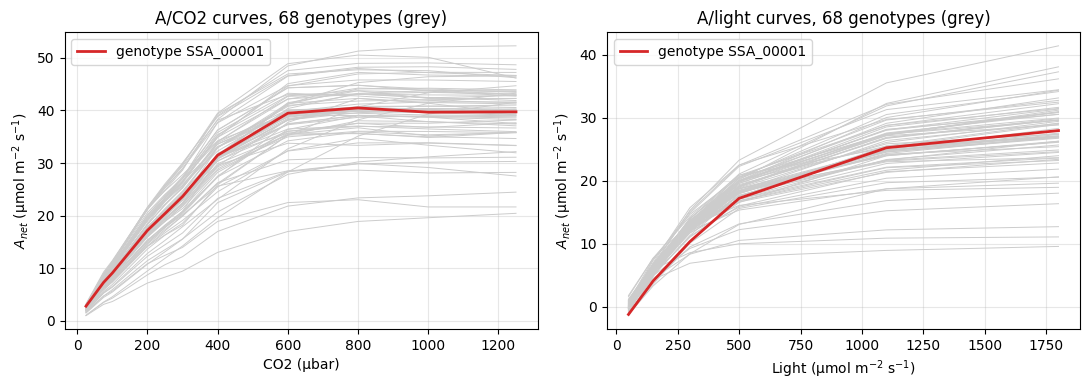

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = os.path.join(PROJECT_ROOT, "data/anet_measurements")
a_co2 = pd.read_csv(os.path.join(DATA_DIR, "a_co2_maize_2022.csv"), index_col=0)
a_light = pd.read_csv(os.path.join(DATA_DIR, "a_light_maize_2022.csv"), index_col=0)
print("A/CO2  table:", a_co2.shape, " first index:", a_co2.index[0])
print("A/light table:", a_light.shape, " first index:", a_light.index[0])
assert a_co2.shape[1] == 11 and a_light.shape[1] == 6, "unexpected curve protocol"

co2_steps = np.array([25, 75, 100, 200, 250, 300, 400, 600, 800, 1000, 1250])   # ubar (README)
light_steps = np.array([50, 150, 300, 500, 1100, 1800])                          # umol m-2 s-1

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for i in range(a_co2.shape[0]):
    axs[0].plot(co2_steps, a_co2.iloc[i].values, color="0.8", lw=0.7)
    axs[1].plot(light_steps, a_light.iloc[i].values, color="0.8", lw=0.7)
for ax, x, y, t in ((axs[0], a_co2, a_light, "A/CO2 (2022)"),
                    (axs[1], a_light, None, "A/light (2022)")):
    pass
axs[0].plot(co2_steps, a_co2.iloc[0].values, color="tab:red", lw=2, label=f"genotype {a_co2.index[0]}")
axs[1].plot(light_steps, a_light.iloc[0].values, color="tab:red", lw=2, label=f"genotype {a_light.index[0]}")
axs[0].set(xlabel="CO2 (µbar)", ylabel=r"$A_{net}$ (µmol m$^{-2}$ s$^{-1}$)", title="A/CO2 curves, 68 genotypes (grey)")
axs[1].set(xlabel=r"Light (µmol m$^{-2}$ s$^{-1}$)", ylabel=r"$A_{net}$ (µmol m$^{-2}$ s$^{-1}$)", title="A/light curves, 68 genotypes (grey)")
for ax in axs:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Run C4TUNE — 予測の実行

Executes the author's own pipeline, unmodified: build the merged config (`config/base.yaml` +
`config/c4tune.yaml`), set the seeded/deterministic environment, load the 236-parameter
`ParameterPredictionModel` (two LSTM curve-encoding branches → 128-d encodings → dense head →
`exp(L·x)`), load the pretrained weights into a `C4tunePredictor`, and predict parameters for all
68 genotypes from the measured curves. Normalization uses the test-set statistics from the author
cache; the raw network output is multiplied by the mean parameter vector (`p_av`) and
exponentiated through L, exactly as in `c4tune/prediction/c4tune_predictor.py`.

**入力:** 実測カーブ、重み、キャッシュ、L。 **出力:** `pred_params` — shape (68, 236) の予測パラメータ行列。


In [ ]:
import torch
from torch import FloatTensor
from c4tune.models.model_c4tune import ParameterPredictionModel
from c4tune.prediction.c4tune_predictor import C4tunePredictor
from c4tune.utils.env_setup import set_training_environment, get_config

# --- author code path (minimal_example_prediction.py, adapted only in data sourcing) ---
base_config_file = os.path.join(PROJECT_ROOT, "config/base.yaml")
c4tune_config_file = os.path.join(PROJECT_ROOT, "config/c4tune.yaml")
config_c4tune = get_config(base_config_file, c4tune_config_file)

np.random.seed(config_c4tune.training.rng_seed)

c4tune_checkpoint = ckpt                       # .../c4tune/2025-03-21/c4tune-epoch-60.pth
L = np.loadtxt(config_c4tune.paths.cholesky_test, delimiter=",")   # the file placed in section 4/5

set_training_environment(config_c4tune)
# author's line kept verbatim: config training.device is "cpu", so inference runs on CPU
device = torch.device(config_c4tune.training.device if torch.cuda.is_available() else "cpu")
print("device:", device)

c4tune_model = ParameterPredictionModel(config_c4tune.model, L=FloatTensor(L))
c4tune = C4tunePredictor(c4tune_model, c4tune_checkpoint, device, config_c4tune)
# (the predictor reads env_input + data_stats from the author's cache file automatically)

env_input = cache_obj["env_input"]             # {co2_steps, light_a_co2, light_steps, co2_a_light}
curve_input = {"a_co2": a_co2.to_numpy(float), "a_light": a_light.to_numpy(float)}

t2 = time.time()
pred_params = c4tune.predict(curve_input, env_input)
print(f"prediction done in {time.time()-t2:.2f} s")
print("pred_params shape:", pred_params.shape)   # (68 genotypes, 236 parameters)
assert pred_params.shape == (68, 236)
assert np.isfinite(pred_params).all(), "non-finite parameter predictions"


device: cpu
	Reading cache from /content/C4TUNE/outputs/cache/c4tune.json.


prediction done in 0.33 s
pred_params shape: (68, 236)


## 8. Results — 予測パラメータの表と図

Builds a readable results table. The 236 parameters are identified with the authors'
`data/parameter_info/parameter_info.xlsx` (name column is read flexibly; if the workbook layout
differs, generic `parameter_i` labels are used rather than guessed names). We show the predicted
values for the first few genotypes, export all 68×236 predictions to CSV, and plot two widely used
photosynthetic capacities across genotypes as an additional notebook-made visualization (this plot
is not a paper figure).

**入力:** 予測行列、parameter_info.xlsx。 **出力:** 表、CSV エクスポート、遺伝型別プロット。


In [ ]:
xlsx_path = os.path.join(PROJECT_ROOT, "data/parameter_info/parameter_info.xlsx")
param_names = None
try:
    info = pd.read_excel(xlsx_path)
    name_col = next((c for c in info.columns
                     if str(c).strip().lower() in ("name", "parameter", "parameter_name", "id")), None)
    if name_col is not None and len(info) >= 236:
        param_names = [str(v) for v in info[name_col].iloc[:236]]
        print("parameter names loaded from", os.path.relpath(xlsx_path, PROJECT_ROOT),
              f"({len(param_names)} names)")
    else:
        print("workbook columns:", list(info.columns), "rows:", len(info))
except Exception as e:
    print("parameter_info.xlsx not readable (%s); using generic labels" % e)
if param_names is None:
    param_names = [f"parameter_{i}" for i in range(236)]

pred_df = pd.DataFrame(pred_params, index=a_co2.index.astype(str), columns=param_names)
pred_df.index.name = "genotype"

# show a compact, inspectable table for the first three genotypes
show_cols = param_names[:8]
print("Predicted parameters (first 8 of 236, first 3 genotypes):")
display(pred_df[show_cols].head(3))

out_csv = "/content/c4tune_predicted_params_maize_2022.csv"
pred_df.to_csv(out_csv)
print("full prediction table exported to", out_csv, pred_df.shape)

# pick a few named parameters for the overview plot, if recognizable names exist
def find_param(*keys):
    for i, n in enumerate(param_names):
        ln = n.lower()
        if all(k in ln for k in keys):
            return i
    return None

candidates = [("Vcmax (RuBisCO carboxylation Vmax)", find_param("vmax", "rubisco")
               or find_param("vcmax")),
              ("Vpmax (PEPC Vmax)", find_param("vmax", "pep") or find_param("vpmax"))]
plot_pairs = [(label, i) for label, i in candidates if i is not None]
if plot_pairs:
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = np.arange(len(pred_df))
    for label, i in plot_pairs:
        ax.plot(xs, pred_df.iloc[:, i], marker="o", ms=3, label=f"{label}  [{param_names[i]}]")
    ax.set(xlabel="genotype index (2022 MAGIC maize)", ylabel="predicted value (model units)")
    ax.set_title("Predicted kinetic parameters per genotype — notebook-made visualization,\nnot a paper figure")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("no recognizable parameter names for the overview plot; see exported CSV")


parameter names loaded from data/parameter_info/parameter_info.xlsx (236 names)
Predicted parameters (first 8 of 236, first 3 genotypes):


,Km1_CO2,Km2_HCO3,Km2_PEP,Ki2_MAL,Ki2_MALn,Km3_NADPH,Km3_OAA,Km3_NADP
genotype,,,,,,,,
SSA_00001,2.379981,0.028738,0.054846,10.065574,1.346662,0.023757,0.059640,0.052763
SSA_00003,2.308459,0.029320,0.066007,10.785021,1.395779,0.026806,0.058892,0.047678
SSA_00004,2.446422,0.027206,0.056019,10.277181,1.338281,0.024489,0.059637,0.050128


full prediction table exported to /content/c4tune_predicted_params_maize_2022.csv (68, 236)
no recognizable parameter names for the overview plot; see exported CSV


## 9. Interpretation and limitations — 解釈と限界

**What was executed:** the authors' pretrained C4TUNE network (pinned commit `8796b700dc001ce3de0f59b1a1481778cc74bbe8`, checkpoint
`c4tune-epoch-60.pth`) predicted all 236 kinetic parameters of the Wang et al. (2021) C4
photosynthesis model for the 68 field-grown MAGIC maize genotypes (2022 season) from their measured
A/CO₂ and A/light curves, exactly following the repository's `minimal_example_prediction.py`.
Predictions are feasible-by-construction: the Cholesky transform maps network outputs into the
log-covariance structure of the authors' biologically filtered training distribution.

**What this demo does not establish:** training correctness, the surrogate model, ODE re-simulation
of predicted parameters (Matlab), the 2023 season, measurement-uncertainty analysis, and the
limiting-factor analysis (paper Figs. 4–6). A 68-genotype prediction run does not verify the
published median relative parameter error (0.30 ± 0.16 on the synthetic test set) or the
Anet-MSE values reported for 2022 (2.26 surrogate / 2.38 kinetic model).

**実行内容と限界（日本語）:** 著者 pretrained モデルにより 2022 年の実測曲線 68 遺伝型分から 236 パラメータを予測しました。
学習・ODE 再シミュレーション・2023 年データ・限定因子解析は未実行で、論文の精度指標（相対誤差 0.30 等）の検証には
なっていません。予測値は参考値としてご覧ください。

**Sources:** paper DOI 10.1111/nph.71280 (CC-BY 4.0) · code github.com/pwendering/C4TUNE @ `8796b700dc001ce3de0f59b1a1481778cc74bbe8`
· weights `outputs/runs/c4tune/2025-03-21/c4tune-epoch-60.pth` · stats cache `outputs/cache/c4tune.json`
· measured curves `data/anet_measurements/*_2022.csv` · Cholesky matrix from Zenodo record 15926601
(doi:10.5281/zenodo.15926601). All downloads occurred inside this notebook; no credentials are used.

**Runtime record:** the validation runtime that produced the saved outputs in this notebook is
stated in `report.md` accompanying this notebook (CPU recommended; see section "Runtime selection").
